ГЛУБОКИЙ АНАЛИЗ ВОЗВРАТОВ + МОДЕЛЬ ПРОГНОЗИРОВАНИЯ
ШВЕЙНОЕ ПРОИЗВОДСТВО

📂 Загрузка данных...

📊 Колонки в articles: ['article_id', 'sku', 'product_type_name', 'colour_group_name', 'season', 'size', 'price', 'cost', 'margin', 'margin_percent']
📊 Колонки в transactions: ['t_dat', 'customer_id', 'article_id', 'sales_channel', 'product_type_name', 'colour_group_name', 'season', 'size', 'price', 'cost', 'margin', 'sku', 'typical_size', 'age', 'gender', 'city', 'warehouse', 'return_prob', 'is_returned', 'return_date', 'return_loss']
✅ Данные загружены: 101,089 транзакций

1. ГЛУБОКИЙ АНАЛИЗ ВОЗВРАТОВ ПО РАЗМЕРАМ

📊 ТОП-10 РАЗМЕРОВ ПО ВОЗВРАТАМ:
      total_orders  returns  return_rate  avg_price
size                                               
42           14118     7404         52.4   7609.288
40           13461     6963         51.7   7579.282
44           13110     6723         51.3   7712.278
46           14789     7580         51.3   7743.799
50           14713     7517         51.1

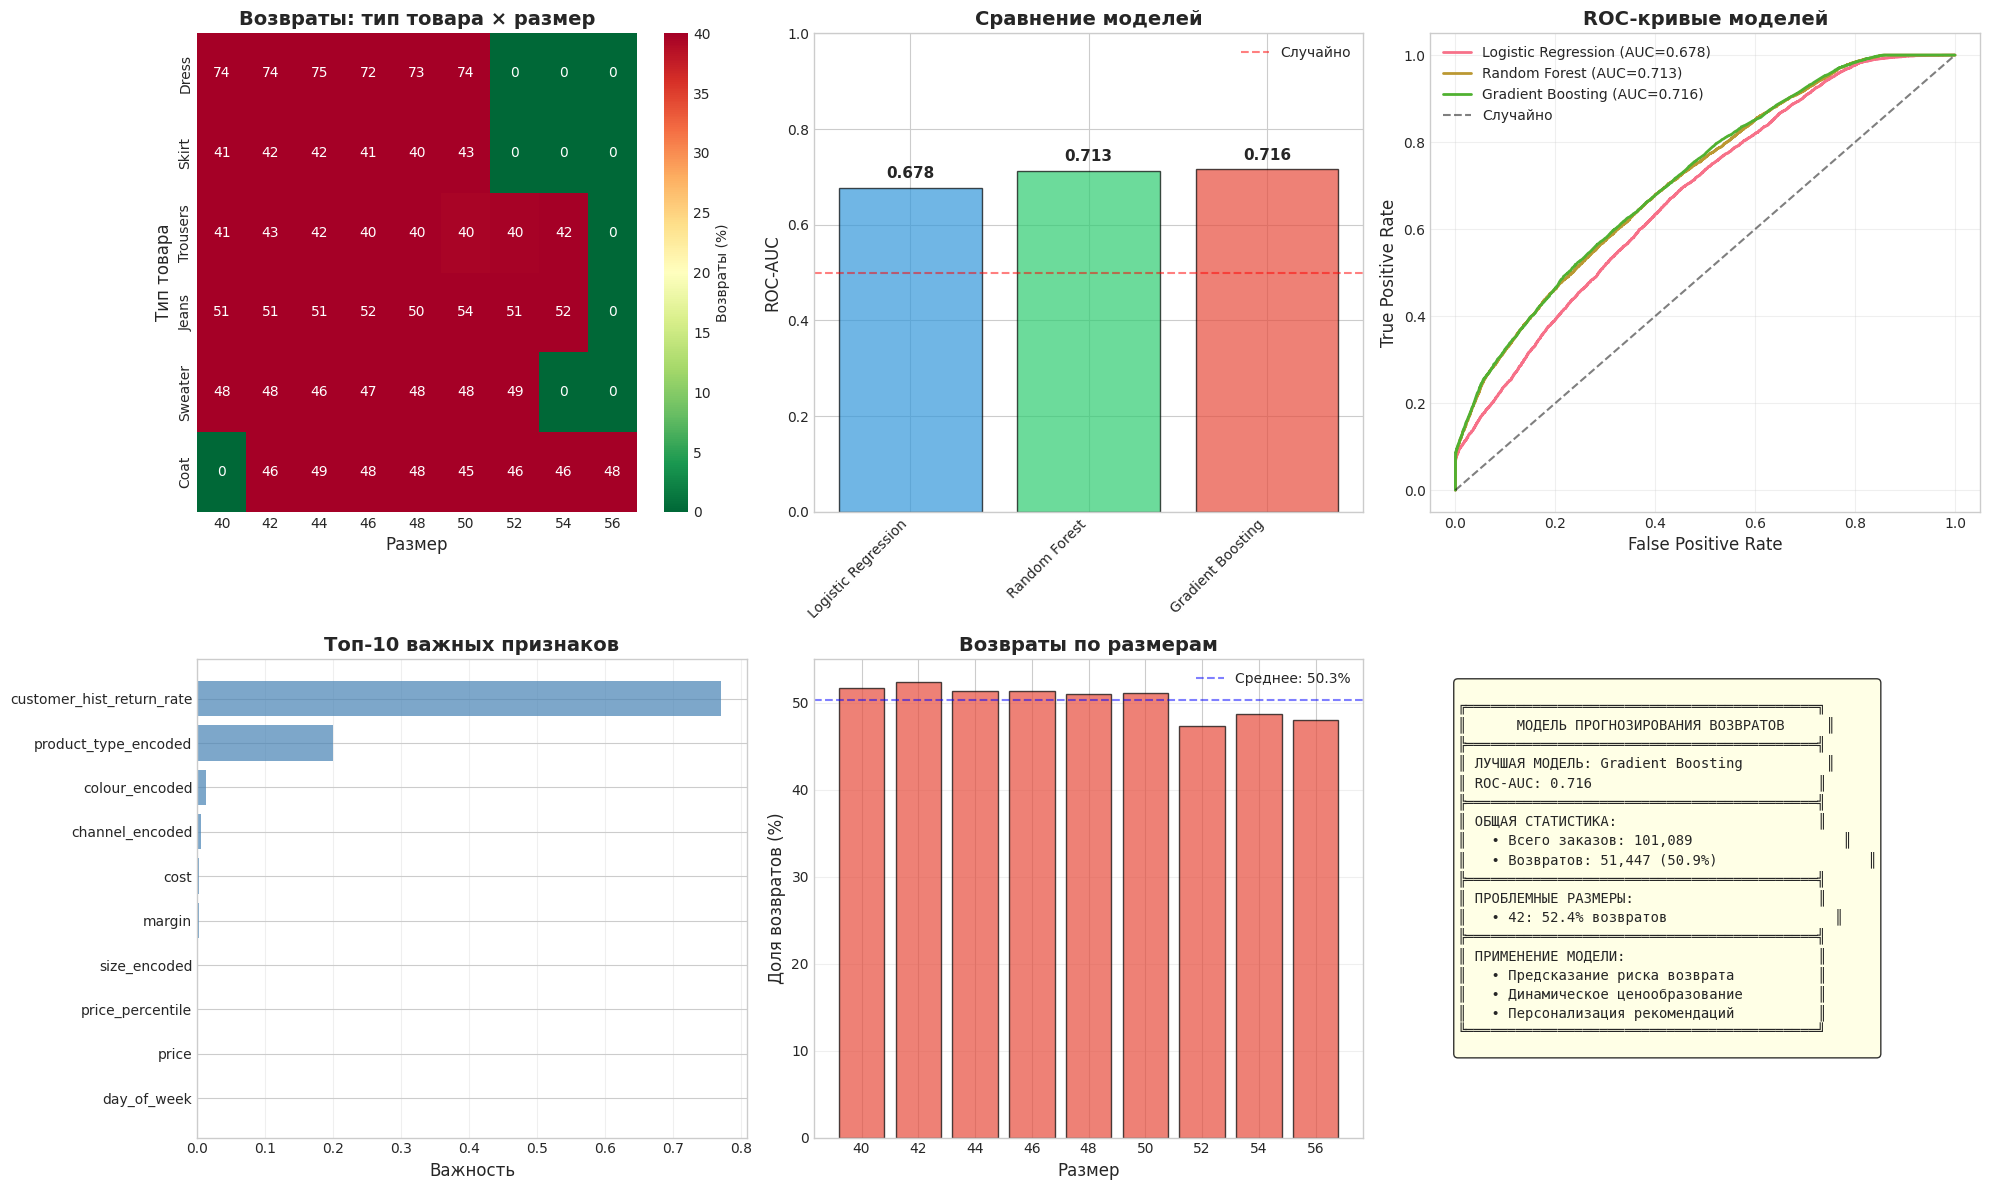

✅ Визуализация сохранена: returns_model_final.png

✅ Файлы сохранены:
   • returns_model.pkl (модель)
   • size_returns.csv (возвраты по размерам)
   • size_type_returns.csv (возвраты по типу×размеру)

МОДЕЛЬ ГОТОВА!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['font.family'] = 'DejaVu Sans'

print("=" * 80)
print("ГЛУБОКИЙ АНАЛИЗ ВОЗВРАТОВ + МОДЕЛЬ ПРОГНОЗИРОВАНИЯ")
print("ШВЕЙНОЕ ПРОИЗВОДСТВО")
print("=" * 80)

# ============================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================
print("\n📂 Загрузка данных...")

transactions = pd.read_csv('transactions.csv', sep=';', encoding='utf-8', decimal=',')
articles = pd.read_csv('articles.csv', sep=';', encoding='utf-8', decimal=',')

print(f"\n📊 Колонки в articles: {articles.columns.tolist()}")
print(f"📊 Колонки в transactions: {transactions.columns.tolist()}")

transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
if 'return_date' in transactions.columns:
    transactions['return_date'] = pd.to_datetime(transactions['return_date'])

transactions['size'] = transactions['size'].astype(str)
articles['size'] = articles['size'].astype(str)

print(f"✅ Данные загружены: {len(transactions):,} транзакций")

# ============================================
# 2. ГЛУБОКИЙ АНАЛИЗ ВОЗВРАТОВ ПО РАЗМЕРАМ
# ============================================
print("\n" + "=" * 80)
print("1. ГЛУБОКИЙ АНАЛИЗ ВОЗВРАТОВ ПО РАЗМЕРАМ")
print("=" * 80)

size_stats = transactions.groupby('size').agg({
    'article_id': 'count',
    'is_returned': ['sum', 'mean'],
    'price': 'mean'
}).round(3)

size_stats.columns = ['total_orders', 'returns', 'return_rate', 'avg_price']
size_stats['return_rate'] = size_stats['return_rate'] * 100
size_stats = size_stats.sort_values('return_rate', ascending=False)

print("\n📊 ТОП-10 РАЗМЕРОВ ПО ВОЗВРАТАМ:")
print(size_stats.head(10).to_string())

# 2.2 Возвраты по размерам в разрезе типов товаров
size_type_stats = transactions.groupby(['product_type_name', 'size']).agg({
    'article_id': 'count',
    'is_returned': 'mean'
}).round(3)
size_type_stats['is_returned'] = size_type_stats['is_returned'] * 100
size_type_stats = size_type_stats[size_type_stats['article_id'] > 30]

problem_combos = size_type_stats[size_type_stats['is_returned'] > 20].sort_values('is_returned', ascending=False)

print("\n🔴 ПРОБЛЕМНЫЕ КОМБИНАЦИИ (возвраты > 20%):")
if len(problem_combos) > 0:
    print(problem_combos.head(15).to_string())
else:
    print("   Нет комбинаций с возвратами > 20%")

# ============================================
# 3. ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ
# ============================================
print("\n" + "=" * 80)
print("2. ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ")
print("=" * 80)

model_data = transactions.copy()

# 3.1 Добавляем cost
if 'cost' in transactions.columns:
    print("   ✅ Используем cost из transactions")
elif 'cost' in articles.columns:
    model_data = model_data.merge(articles[['article_id', 'cost']], on='article_id', how='left')
    print("   ✅ Добавлен cost из articles")
else:
    model_data['cost'] = model_data['price'] * 0.5
    print("   ⚠️ cost оценен как 50% от price")

# 3.2 Создаем margin ПОСЛЕ того как cost точно есть
if 'cost' in model_data.columns:
    model_data['margin'] = model_data['price'] - model_data['cost']
    print("   ✅ margin рассчитан")

# 3.3 Признаки клиента
if 'customer_id' in model_data.columns:
    customer_freq = model_data[model_data['customer_id'] > 0].groupby('customer_id').size()
    model_data['customer_freq'] = model_data['customer_id'].map(customer_freq).fillna(1).astype(int)

    customer_return_rate = model_data[model_data['customer_id'] > 0].groupby('customer_id')['is_returned'].mean()
    model_data['customer_hist_return_rate'] = model_data['customer_id'].map(customer_return_rate).fillna(model_data['is_returned'].mean())
    print("   ✅ Признаки клиента добавлены")
else:
    model_data['customer_freq'] = 1
    model_data['customer_hist_return_rate'] = model_data['is_returned'].mean()

# 3.4 Временные признаки
model_data['month'] = model_data['t_dat'].dt.month
model_data['day_of_week'] = model_data['t_dat'].dt.dayofweek
model_data['is_weekend'] = model_data['day_of_week'].isin([5, 6]).astype(int)

# 3.5 Ценовые признаки
model_data['price_percentile'] = model_data['price'].rank(pct=True)

# 3.6 Кодирование категорий
le_product = LabelEncoder()
le_colour = LabelEncoder()
le_size = LabelEncoder()

model_data['product_type_encoded'] = le_product.fit_transform(model_data['product_type_name'].astype(str))
model_data['colour_encoded'] = le_colour.fit_transform(model_data['colour_group_name'].astype(str))
model_data['size_encoded'] = le_size.fit_transform(model_data['size'].astype(str))

if 'sales_channel' in model_data.columns:
    le_channel = LabelEncoder()
    model_data['channel_encoded'] = le_channel.fit_transform(model_data['sales_channel'].astype(str))

print(f"✅ Подготовлено признаков: {len(model_data.columns)}")

# ============================================
# 4. ОТБОР ПРИЗНАКОВ
# ============================================
# Формируем список доступных признаков
available_features = []

# Базовые признаки (точно есть)
base_features = ['price', 'product_type_encoded', 'colour_encoded', 'size_encoded',
                 'month', 'day_of_week', 'is_weekend', 'customer_freq', 'customer_hist_return_rate']
for f in base_features:
    if f in model_data.columns:
        available_features.append(f)

# Дополнительные признаки (если есть)
optional_features = ['cost', 'margin', 'price_percentile', 'channel_encoded']
for f in optional_features:
    if f in model_data.columns and model_data[f].notna().any():
        available_features.append(f)

print(f"\n📊 Доступные признаки ({len(available_features)}):")
for f in available_features:
    print(f"   • {f}")

# Убираем строки с пропусками
model_clean = model_data.dropna(subset=available_features + ['is_returned'])

X = model_clean[available_features]
y = model_clean['is_returned']

print(f"\n📊 РАЗМЕР ДАННЫХ ДЛЯ МОДЕЛИ:")
print(f"   • Всего записей: {len(X):,}")
print(f"   • Признаков: {len(available_features)}")
print(f"   • Доля возвратов: {y.mean()*100:.1f}%")

# ============================================
# 5. ОБУЧЕНИЕ МОДЕЛЕЙ
# ============================================
print("\n" + "=" * 80)
print("3. ОБУЧЕНИЕ МОДЕЛЕЙ ПРОГНОЗИРОВАНИЯ")
print("=" * 80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 РАЗДЕЛЕНИЕ ДАННЫХ:")
print(f"   • Обучающая выборка: {len(X_train):,}")
print(f"   • Тестовая выборка: {len(X_test):,}")

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, max_depth=4, random_state=42)
}

results = {}
for name, model in models.items():
    print(f"\n🔧 Обучение {name}...")
    model.fit(X_train, y_train)

    y_pred_proba = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    results[name] = {
        'model': model,
        'roc_auc': roc_auc,
        'y_pred_proba': y_pred_proba
    }

    print(f"   • ROC-AUC: {roc_auc:.4f}")

best_model_name = max(results, key=lambda x: results[x]['roc_auc'])
best_model = results[best_model_name]['model']

print(f"\n✅ ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
print(f"   • ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")

# ============================================
# 6. ВАЖНОСТЬ ПРИЗНАКОВ
# ============================================
print("\n" + "=" * 80)
print("4. ВАЖНОСТЬ ПРИЗНАКОВ")
print("=" * 80)

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_importance = pd.DataFrame({
        'feature': available_features,
        'importance': importances
    }).sort_values('importance', ascending=False)

    print("\n📊 ТОП-10 ВАЖНЫХ ПРИЗНАКОВ:")
    for _, row in feature_importance.head(10).iterrows():
        print(f"   • {row['feature']}: {row['importance']:.4f}")

# ============================================
# 7. ВИЗУАЛИЗАЦИЯ
# ============================================
print("\n" + "=" * 80)
print("5. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("=" * 80)

fig = plt.figure(figsize=(20, 12))

# 7.1 Тепловая карта: размер × тип товара
ax1 = plt.subplot(2, 3, 1)
pivot_size_type = size_type_stats.reset_index().pivot_table(
    index='product_type_name',
    columns='size',
    values='is_returned',
    fill_value=0
)
top_cats = transactions['product_type_name'].value_counts().head(6).index
pivot_size_type = pivot_size_type.reindex([c for c in top_cats if c in pivot_size_type.index])

sns.heatmap(pivot_size_type, annot=True, fmt='.0f', cmap='RdYlGn_r', ax=ax1,
            cbar_kws={'label': 'Возвраты (%)'}, vmax=40)
ax1.set_title('Возвраты: тип товара × размер', fontsize=14, fontweight='bold')
ax1.set_xlabel('Размер', fontsize=12)
ax1.set_ylabel('Тип товара', fontsize=12)

# 7.2 Сравнение моделей
ax2 = plt.subplot(2, 3, 2)
model_names = list(results.keys())
roc_scores = [results[name]['roc_auc'] for name in model_names]
colors = ['#3498db', '#2ecc71', '#e74c3c'][:len(model_names)]
bars = ax2.bar(range(len(model_names)), roc_scores, color=colors, edgecolor='black', alpha=0.7)
ax2.set_xticks(range(len(model_names)))
ax2.set_xticklabels(model_names, rotation=45, ha='right')
ax2.set_ylabel('ROC-AUC', fontsize=12)
ax2.set_title('Сравнение моделей', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 1)
ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Случайно')
ax2.legend()
for bar, val in zip(bars, roc_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

# 7.3 ROC-кривые
ax3 = plt.subplot(2, 3, 3)
for name in results:
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_pred_proba'])
    ax3.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={results[name]['roc_auc']:.3f})")
ax3.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Случайно')
ax3.set_xlabel('False Positive Rate', fontsize=12)
ax3.set_ylabel('True Positive Rate', fontsize=12)
ax3.set_title('ROC-кривые моделей', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 7.4 Важность признаков
ax4 = plt.subplot(2, 3, 4)
if 'feature_importance' in locals():
    top_features = feature_importance.head(10)
    bars = ax4.barh(range(len(top_features)), top_features['importance'],
                    color='steelblue', alpha=0.7)
    ax4.set_yticks(range(len(top_features)))
    ax4.set_yticklabels(top_features['feature'])
    ax4.set_xlabel('Важность', fontsize=12)
    ax4.set_title('Топ-10 важных признаков', fontsize=14, fontweight='bold')
    ax4.invert_yaxis()
    ax4.grid(True, alpha=0.3, axis='x')

# 7.5 Возвраты по размерам
ax5 = plt.subplot(2, 3, 5)
size_returns_plot = size_stats.sort_index()
colors_size = ['#e74c3c' if x > 20 else '#f39c12' if x > 10 else '#2ecc71'
               for x in size_returns_plot['return_rate']]
bars = ax5.bar(range(len(size_returns_plot)), size_returns_plot['return_rate'],
               color=colors_size, edgecolor='black', alpha=0.7)
ax5.set_xticks(range(len(size_returns_plot)))
ax5.set_xticklabels(size_returns_plot.index)
ax5.set_xlabel('Размер', fontsize=12)
ax5.set_ylabel('Доля возвратов (%)', fontsize=12)
ax5.set_title('Возвраты по размерам', fontsize=14, fontweight='bold')
ax5.axhline(y=size_stats['return_rate'].mean(), color='blue', linestyle='--',
            alpha=0.5, label=f"Среднее: {size_stats['return_rate'].mean():.1f}%")
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# 7.6 Выводы
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

worst_size = size_stats.index[0] if len(size_stats) > 0 else 'N/A'
worst_rate = size_stats.iloc[0]['return_rate'] if len(size_stats) > 0 else 0

summary_text = f"""
╔══════════════════════════════════════════╗
║     МОДЕЛЬ ПРОГНОЗИРОВАНИЯ ВОЗВРАТОВ     ║
╠══════════════════════════════════════════╣
║ ЛУЧШАЯ МОДЕЛЬ: {best_model_name[:20]:<20}║
║ ROC-AUC: {results[best_model_name]['roc_auc']:.3f}║
╠══════════════════════════════════════════╣
║ ОБЩАЯ СТАТИСТИКА:                        ║
║   • Всего заказов: {len(transactions):,} ║
║   • Возвратов: {y.sum():,} ({y.mean()*100:.1f}%)║
╠══════════════════════════════════════════╣
║ ПРОБЛЕМНЫЕ РАЗМЕРЫ:                      ║
║   • {worst_size}: {worst_rate:.1f}% возвратов
╠══════════════════════════════════════════╣
║ ПРИМЕНЕНИЕ МОДЕЛИ:                       ║
║   • Предсказание риска возврата          ║
║   • Динамическое ценообразование         ║
║   • Персонализация рекомендаций          ║
╚══════════════════════════════════════════╝
"""

ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('returns_model_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Визуализация сохранена: returns_model_final.png")

# ============================================
# 8. СОХРАНЕНИЕ
# ============================================
import joblib

joblib.dump(best_model, 'returns_model.pkl')
size_stats.to_csv('size_returns.csv', encoding='utf-8-sig', sep=';', decimal=',')
size_type_stats.to_csv('size_type_returns.csv', encoding='utf-8-sig', sep=';', decimal=',')

print("\n✅ Файлы сохранены:")
print("   • returns_model.pkl (модель)")
print("   • size_returns.csv (возвраты по размерам)")
print("   • size_type_returns.csv (возвраты по типу×размеру)")

print("\n" + "=" * 80)
print("МОДЕЛЬ ГОТОВА!")
print("=" * 80)